# COMPARISON OF PERCEPTION VARIABILITY USING RTI AND VRTI METHODOLOGIES

In [15]:
# Importing the libraries needed for the process

from pathlib import Path
import cv2
import numpy as np
import os
from scipy.spatial import cKDTree
import csv
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

**Step 1: Image processing and point cloud extraction (PNG to XYZ)**
The goal of this first step is to convert the manual tracings (PNG images) into spatial data (XYZ point clouds).
- **Logic**: The script scans images for Green (Footprint) and Yellow (Detail) pixels using BGR color masks.
- **Coordinate transformation**: It maps pixel coordinates (u, v) to spatial coordinates (x, y, z). Since image rows increase downwards, the **Y** axis is inverted (-Y) to maintain correct orientation.
- **Automation**: The process is repeated for RTI, VRTI, and Ground Truth (GT) folders, ensuring all datasets are uniform.

In [16]:
# Configuring paths
base_dir = Path.cwd() / "dataset"

rti_dir = os.path.join(base_dir, "images_rti")
vrti_dir = os.path.join(base_dir, "images_vrti")
gt_path = os.path.join(base_dir, "gt", "1943_groundtruth_perimetro.png")
output_dir_rti = os.path.join(base_dir, "pointclouds_rti")
output_dir_vrti = os.path.join(base_dir, "pointclouds_vrti")

os.makedirs(output_dir_rti, exist_ok=True)
os.makedirs(output_dir_vrti, exist_ok=True)

# === FUNCTION ===
def image_to_pointcloud(image_path, output_path):
    img = cv2.imread(image_path)

    # OpenCV uses BGR
    b, g, r = img[:,:,0], img[:,:,1], img[:,:,2]

    # Tolerance for anti-aliasing
    tol = 10
    
    # Identify the green of the footprint (a)
    mask_green = (
        (r <= tol) &
        (g >= 255 - tol) &
        (b <= tol)
    )
    
    # Identify the yellow of the footprint detail (b)
    mask_yellow = (
        (r >= 255 - tol) &
        (g >= 255 - tol) &
        (b <= tol)
    )

    combined_mask = mask_green | mask_yellow

    points = np.column_stack(np.where(combined_mask))

    if points.size == 0:
        print(f"No points found in {image_path}")
        return

    # Conversion from PNG to XYZ
    xyz = np.zeros((points.shape[0], 3))
    xyz[:, 0] = points[:, 1]   # X = column
    xyz[:, 1] = -points[:, 0]   # Y = inverted axis 
    xyz[:, 2] = 0               # Z

    # Save
    np.savetxt(output_path, xyz, fmt="%.3f")

# Process RTI
for filename in os.listdir(rti_dir):
    if not filename.lower().endswith(".png"):
        continue

    input_path = os.path.join(rti_dir, filename)

    name = os.path.splitext(filename)[0] + "_pointcloud"
    output_path = os.path.join(output_dir_rti, name + ".xyz")

    print(f"Processing {filename}")
    image_to_pointcloud(input_path, output_path)

# Process Ground Truth
gt_output_rti = os.path.join(output_dir_rti, "groundtruth_pointcloud.xyz")
image_to_pointcloud(gt_path, gt_output_rti)

print("\nAll files saved in /pointclouds_rti")

# Process VRTI
for filename in os.listdir(vrti_dir):
    if not filename.lower().endswith(".png"):
        continue

    input_path = os.path.join(vrti_dir, filename)

    name = os.path.splitext(filename)[0] + "_VRTI_pointcloud"
    output_path = os.path.join(output_dir_vrti, name + ".xyz")

    print(f"Processing {filename}")
    image_to_pointcloud(input_path, output_path)

# Process Ground Truth
gt_output_vrti = os.path.join(output_dir_vrti, "groundtruth_pointcloud.xyz")
image_to_pointcloud(gt_path, gt_output_vrti)

print("\nAll files saved in /pointclouds_vrti")

Processing Studente 1(a)_RTI.png
Processing Studente 1(b)_RTI.png
Processing Studente 10(a)_RTI.png
Processing Studente 10(b)_RTI.png
Processing Studente 11(a)_RTI.png
Processing Studente 11(b)_RTI.png
Processing Studente 12(a)_RTI.png
Processing Studente 12(b)_RTI.png
Processing Studente 13(a)_RTI.png
Processing Studente 13(b)_RTI.png
Processing Studente 14(a)_RTI.png
Processing Studente 14(b)_RTI.png
Processing Studente 15(a)_RTI.png
Processing Studente 15(b)_RTI.png
Processing Studente 16(a)_RTI.png
Processing Studente 16(b)_RTI.png
Processing Studente 17(a)_RTI.png
Processing Studente 17(b)_RTI.png
Processing Studente 18(a)_RTI.png
Processing Studente 18(b)_RTI.png
Processing Studente 19(a)_RTI.png
Processing Studente 19(b)_RTI.png
Processing Studente 2(a)_RTI.png
Processing Studente 2(b)_RTI.png
Processing Studente 20(a)_RTI.png
Processing Studente 20(b)_RTI.png
Processing Studente 3(a)_RTI.png
Processing Studente 3(b)_RTI.png
Processing Studente 4(a)_RTI.png
Processing Studente 4

# ANALYSIS OF XYZ FILES RTI and VRTI with the production of csv file for A and B data

**Step 2: Metric calculation (Chamfer Distance)**
This step quantifies the error by comparing each student's point cloud against the Ground Truth.
- **Subsampling**: A grid-based filter is applied to normalise the point density, preventing bias from thicker/thinner or longer/shorter lines.
- **Nearest Neighbour Search**: Using cKDTree for efficiency, the script calculates the distance from every student point to the nearest GT point (and vice-versa).
- **Metric suite**:
  - **RMSE**: Captures overall accuracy, penalising large deviations.
  - **P90**: Shows the error threshold for 90% of the tracing (ignores extreme outliers).
  - **Max**: Identifies the single worst interpretative error.
  - **StdDev**: Measures the consistency of the tracing stroke.

**Step 3: Group Aggregation and CSV Export**
The raw metrics are grouped by category (Group A: Footprint, Group B: Detail) and technology (RTI vs. VRTI).
- **Data Storage**: Four CSV files are generated (distances_rti_a, distances_rti_b, etc.) to store the performance of all 19-20 students per group.
- **Mean Stats**: The script calculates the "Mean of Means" to provide a snapshot of group performance.

In [17]:
# === FUNCTIONS ===

# === SUBSAMPLING (grid-based) ===
def subsample(points, step=1):
    grid = np.floor(points[:, :2] / step)
    _, idx = np.unique(grid, axis=0, return_index=True)
    return points[idx]

# === NN DISTANCE ===
def nn_distance(A, B):
    tree = cKDTree(B)
    dist, _ = tree.query(A)
    return dist

# === BIDIRECTIONAL DISTANCE (Chamfer) ===
def chamfer_distance(A, B):
    d1 = nn_distance(A, B)
    d2 = nn_distance(B, A)

 # Calculating RMSE: Root Mean Square Error
    rmse_d1 = np.sqrt(np.mean(d1**2))
    rmse_d2 = np.sqrt(np.mean(d2**2))

    return {
        "mean": (np.mean(d1) + np.mean(d2)) / 2,
        "rmse": (rmse_d1 + rmse_d2) / 2,
        "std": (np.std(d1) + np.std(d2)) / 2,
        "max": max(np.max(d1), np.max(d2)),
        "p90": (np.percentile(d1, 90) + np.percentile(d2, 90)) / 2
    }

# === CONFIGURATION ===
# Set folders to process: (folder_name, result_suffix)
tasks = [
    ("pointclouds_rti", "rti"),
    ("pointclouds_vrti", "vrti")
]
groups = ["(a)", "(b)"]

# === MAIN GLOBAL LOOP (FOR BOTH A (footprint) AND B (detail)) === # 
for cloud_folder, suffix in tasks:
    data_dir = os.path.join(base_dir, cloud_folder)
    results_dir = os.path.join(base_dir, f"results_{suffix}")
    gt_path = os.path.join(data_dir, "groundtruth_pointcloud.xyz")

    os.makedirs(results_dir, exist_ok=True)

    print(f"\n STARTING ANALYSIS FOR: {cloud_folder.upper()}")

    # Pre-process GT once per main folder
    if not os.path.exists(gt_path):
        print(f" Skipping {cloud_folder}: GT not found at {gt_path}")
        continue
    
    gt = np.loadtxt(gt_path)
    gt = subsample(gt, step=1)

    for group in groups:
        results = []
        clean_group = group.strip('()')
        output_file = os.path.join(results_dir, f"distances_{suffix}_{clean_group}.csv")

 # Correct logic: file must contain both "Studente" AND the specific group suffix       
        for file in os.listdir(data_dir):
            if "Studente" in file and group in file:
                path = os.path.join(data_dir, file)
                
                try:
                    student = np.loadtxt(path, dtype=float)
                    if np.isnan(student).any(): continue
                    
                    # Apply subsampling and calculate distances to student data
                    
                    student_sub = subsample(student, step=1)
                    metrics = chamfer_distance(student_sub, gt)

                    results.append([
                        file, metrics["mean"], metrics["rmse"], 
                        metrics["std"], metrics["max"], metrics["p90"]
                    ])
                except:
                    continue

        # === SAVE RESULTS TO CSV ===
        
        if results:
            with open(output_file, "w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(["File", "Mean", "RMSE", "StdDev", "Max", "P90"])
                writer.writerows(results)

            # === SHOW SUMMARY STATS ===
            df = pd.read_csv(output_file)
            summary = {
                "RMSE_mean": df["RMSE"].mean(),
                "P90_mean": df["P90"].mean(),
                "Max_total_mean": df["Max"].mean(),
                "StdDev_mean": df["StdDev"].mean(),
                "Mean_mean": df["Mean"].mean()
            }
    
            print(f"Analysis saved to output file")
            print(f"GROUP {group} STATS:")
            for k, v in summary.items():
                print(f"  {k}: {v:.4f}")
        else:
            print(f"No files found for group {group}")

print("\n All RTI and VRTI analyses completed")


 STARTING ANALYSIS FOR: POINTCLOUDS_RTI
Analysis saved to output file
GROUP (a) STATS:
  RMSE_mean: 58.5080
  P90_mean: 107.0257
  Max_total_mean: 287.2990
  StdDev_mean: 43.8942
  Mean_mean: 38.1002
Analysis saved to output file
GROUP (b) STATS:
  RMSE_mean: 187.5253
  P90_mean: 293.7730
  Max_total_mean: 545.5092
  StdDev_mean: 108.5430
  Mean_mean: 152.0167

 STARTING ANALYSIS FOR: POINTCLOUDS_VRTI
Analysis saved to output file
GROUP (a) STATS:
  RMSE_mean: 63.3059
  P90_mean: 118.2327
  Max_total_mean: 282.4583
  StdDev_mean: 47.1330
  Mean_mean: 41.6053
Analysis saved to output file
GROUP (b) STATS:
  RMSE_mean: 188.4532
  P90_mean: 291.4929
  Max_total_mean: 575.0835
  StdDev_mean: 101.5469
  Mean_mean: 158.1438

 All RTI and VRTI analyses completed


# DATA COMPARISON - VRTI RTI

**Step 4: Statistical Testing and Visualisation**
The final step determines if the differences between RTI and VRTI are scientifically relevant.
- **Mann-Whitney U Test**: A non-parametric test chosen for its robustness with small sample sizes (N≈20) and its ability to handle non-normal distributions.
- **Boxplot visualization**:
  - **Boxes**: Represent the distribution and median of the RMSE.
  - **Jitter Points**: Individual student results are plotted to visualize the spread and identify outliers.
  - **P-Value interpretation**: A value confirms that RTI and VRTI are statistically equivalent.


--- Results for Group A ---
RTI mean RMSE: 58.5080 | VRTI mean RMSE: 63.3059
p-value: 0.19137
The comparison is not statistically significant


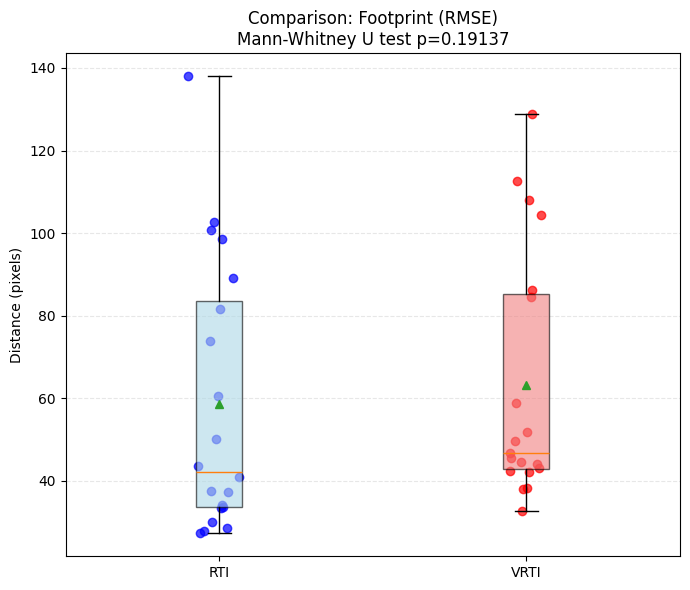


--- Results for Group B ---
RTI mean RMSE: 187.5253 | VRTI mean RMSE: 188.4532
p-value: 0.09456
The comparison is not statistically significant


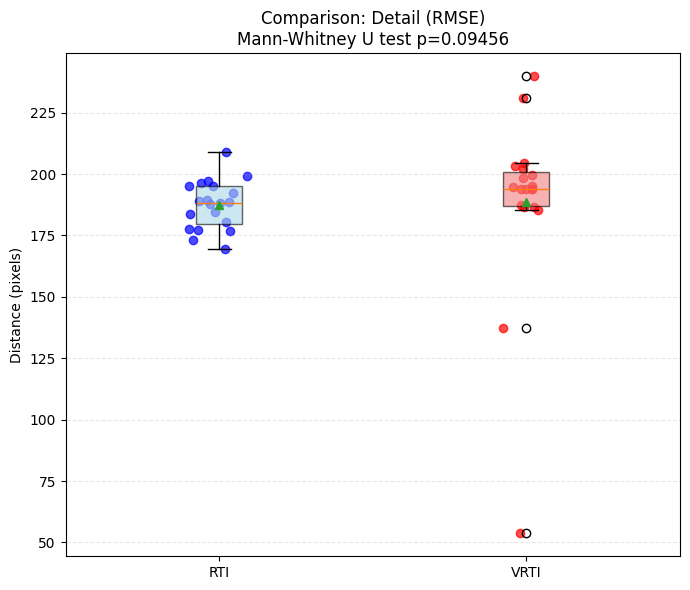


Comparison analysis completed.


In [18]:
# === CONFIGURATION ===
results_rti_dir = "dataset/results_rti"
results_vrti_dir = "dataset/results_vrti"
groups = ["a", "b"]

for group in groups:
    # Build file paths
    rti_path = os.path.join(results_rti_dir, f"distances_rti_{group}.csv")
    vrti_path = os.path.join(results_vrti_dir, f"distances_vrti_{group}.csv")
    
    if not os.path.exists(rti_path) or not os.path.exists(vrti_path):
        print(f"Skipping group {group}: files not found.")
        continue

    # === LOAD AND CLEAN ===
    rti_df = pd.read_csv(rti_path)
    vrti_df = pd.read_csv(vrti_path)
    
    r = pd.to_numeric(rti_df["RMSE"], errors="coerce").dropna()
    v = pd.to_numeric(vrti_df["RMSE"], errors="coerce").dropna()

    # === STATISTICAL TEST (Mann-Whitney U) ===
    # Using this as it's robust for small samples (19-20)
    stat, p = mannwhitneyu(r, v)
    print(f"\n--- Results for Group {group.upper()} ---")
    print(f"RTI mean RMSE: {r.mean():.4f} | VRTI mean RMSE: {v.mean():.4f}")
    print(f"p-value: {p:.5f}")

    # === PLOTTING ===
    plt.figure(figsize=(7, 6))
    
    # Boxplot
    box = plt.boxplot([r, v], tick_labels=["RTI", "VRTI"], showmeans=True, patch_artist=True)
    
    # Styling boxes
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    # Add individual points (Jitter)
    plt.scatter(np.random.normal(1, 0.04, size=len(r)), r, alpha=0.7, color='blue', label='RTI Samples')
    plt.scatter(np.random.normal(2, 0.04, size=len(v)), v, alpha=0.7, color='red', label='VRTI Samples')

    # Labels and titles
    group_title = "Footprint" if group == "a" else "Detail"
    plt.ylabel("Distance (pixels)")
    plt.title(f"Comparison: {group_title} (RMSE)\nMann-Whitney U test p={p:.5f}")
    
    # Highlight significance
    if p < 0.05:
        plt.text(1.5, max(r.max(), v.max()), "Statistically Significant", 
                 ha='center', color='darkred', fontweight='bold')
    else:
        print("The comparison is not statistically significant")

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # Optional: save the plot
    # plt.savefig(f"comparison_plot_{group}.png")
    
    plt.show()

print("\nComparison analysis completed.")

# RESULTS

**Final Conclusions of the Study**
1. **Reliability**: VRTI is as accurate as traditional RTI (p-values: 0.19 and 0.09).
2. **Task Sensitivity**: Task complexity is the primary driver of error. RMSE increases from ~60 (a: Footprint) to ~188 (b: Detail), a 300% increase in difficulty regardless of the technique. Tracing fine details is significantly more challenging than defining a general perimeter. Students lose precision when interpreting complex or smaller features. The high Max_total_mean (545–575) in Group B suggests that nearly all participants made at least one major interpretative error during the detail-tracing task.
3. **Consistency**: VRTI showed a slight trend toward better consistency (lower StdDev) in complex details.

# Lighting perspective analysis (RTI vs VRTI)

**Step 5**: In this stage, we analyse the subjective choices made by students regarding the **"best lighting angle"** to perceive fine details. Unlike the previous metric analysis (RMSE), which measured execution accuracy with respect to the ground truth, this study focuses on visual perception. We compare the X,Y coordinates of the light source selected by students using the RTI viewer software.
**Identify patterns**: determine if there is a shared "optimal light" consensus or if the choice is purely subjective.
**Evaluate technology impact**: Test if the virtual model obtained from VRTI shifts or distorts the perception of relief compared to the real rendering obtained from RTI.

--- LIGHTING COORDINATES COMPARISON ---
  Axis  RTI_Mean  VRTI_Mean  RTI_Median  VRTI_Median   p-value
0    X      0.10  -0.063158        0.25         -0.3  0.366689
1    Y     -0.05  -0.200000       -0.15         -0.3  0.343941


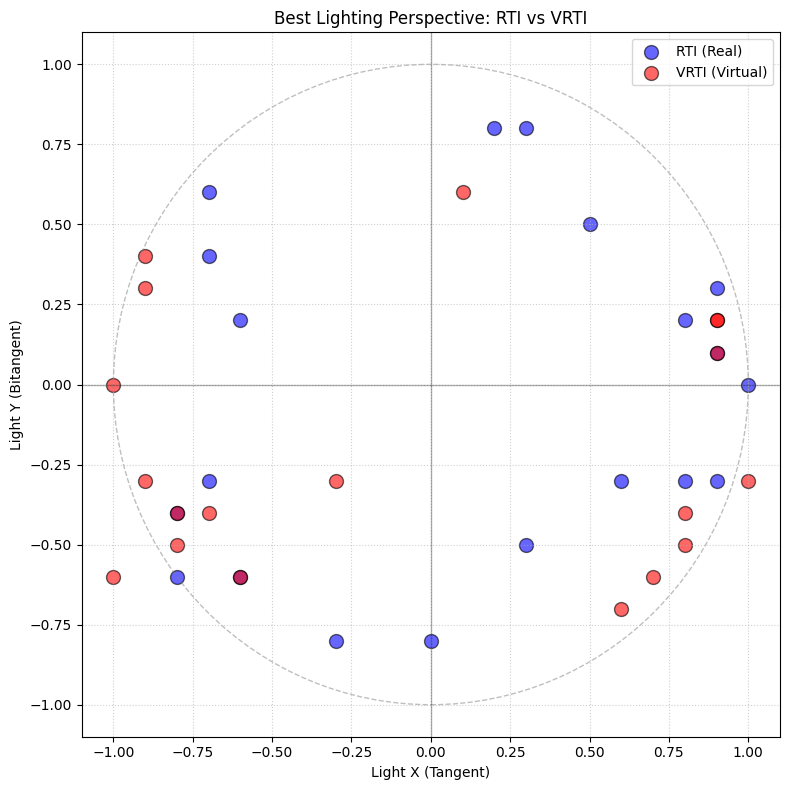

In [22]:
# === Configuring .csv paths ===
results_rti_dir = "dataset/results_rti"
results_vrti_dir = "dataset/results_vrti"

path_rti = os.path.join(results_rti_dir, "RTI_light.csv")
path_vrti = os.path.join(results_vrti_dir, "VRTI_light.csv")

# === LOAD DATA ===
df_rti = pd.read_csv(path_rti)
df_vrti = pd.read_csv(path_vrti)

# === 1. STATISTICAL COMPARISON (Step-by-Step) ===
# Descriptive Statistics and Mann-Whitney U Test
# Comparing X (Tangent) and Y (Bitangent) coordinates for RTI and VRTI

def compare_lights(df1, df2, label1="RTI", label2="VRTI"):
    stats = []
    for axis in ['X', 'Y']:
        val1 = df1[axis].dropna()
        val2 = df2[axis].dropna()
        
        # Calculate Mean and Median
        m1, med1 = val1.mean(), val1.median()
        m2, med2 = val2.mean(), val2.median()
        
        # Mann-Whitney U test to see if the choice distribution differs
        stat, p = mannwhitneyu(val1, val2)
        
        stats.append({
            "Axis": axis,
            f"{label1}_Mean": m1, f"{label2}_Mean": m2,
            f"{label1}_Median": med1, f"{label2}_Median": med2,
            "p-value": p
        })
    return pd.DataFrame(stats)

comparison_results = compare_lights(df_rti, df_vrti)
print("--- LIGHTING COORDINATES COMPARISON ---")
print(comparison_results)

# === 2. VISUALIZATION (Pattern Recognition) ===
# Spatial Distribution of Light Choices
# The plot shows student selections within the RTI hemispherical domain (unit circle).

plt.figure(figsize=(8, 8))

# Plot RTI choices
plt.scatter(df_rti['X'], df_rti['Y'], color='blue', alpha=0.6, label='RTI (Real)', s=100, edgecolors='k')

# Plot VRTI choices
plt.scatter(df_vrti['X'], df_vrti['Y'], color='red', alpha=0.6, label='VRTI (Virtual)', s=100, edgecolors='k')

# Drawing the RTI domain limit (usually a unit circle)
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.5)
plt.gca().add_patch(circle)

# Formatting the plot
plt.axhline(0, color='black', linewidth=1, alpha=0.3)
plt.axvline(0, color='black', linewidth=1, alpha=0.3)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel("Light X (Tangent)")
plt.ylabel("Light Y (Bitangent)")
plt.title("Best Lighting Perspective: RTI vs VRTI")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Discussion of Results**
1. **High Dispersion (Subjectivity)**: the scatter plot reveals a high degree of dispersion. There is no single "cluster" or "magic point" of light; instead, students found the details visible from many different angles. This suggests that the perception of the artifact's micro-topography is highly individual.
2. **Preference for grazing light**: Most selections (both RTI and VRTI) are located near the edge of the circle (values approaching 1.0 or -1.0). This confirms a natural preference for low-angle grazing light, which maximizes the casting of micro-shadows, making the footprint's details more legible.
3. **Statistical equivalency**: The p-values (0.36 and 0.34) are significantly above the 0.05 threshold. This is a crucial finding: the visualization of the footprint, regardless of the technique used to obtain it (RTI and VRTI) do not statistically influence the lighting choice. Students trying the VRTI-generated model perceived the volumes and surface characteristics in the same way as those trying the RTI-generated model.
4. **Metrics**: While the Means show slight differences, the Medians remain relatively central. Given the high variance (dispersion), the Scatter Plot is the most effective tool to demonstrate that both groups explored the light dome with similar "spatial behavior."

**Conclusions**
The VRTI system is a perceptually reliable tool. It provides a lighting interaction that is consistent with traditional RTI, allowing users to identify and highlight morphological features without bias due to the technique used.